Let $H_{x,u}=\{y\in\mathbb{R}^d:u'(y-x)\geqslant 0\}$. If $X\sim N(\mu,\Sigma)$, then $Y=u'X\sim N(u'\mu, u'\Sigma u)$. Then 
\begin{equation}
\mathbb{P}(X\in H_{x,u})=\mathbb{P}(u'X\geqslant u'x)=\mathbb{P}(Y\geqslant u'x).
\end{equation}
Consequently, let $Y\sim N(\mu,\sigma^2)$, then
\begin{equation}
\mathbb{P}(Y\geqslant u'x)=1-\Phi\left(\frac{u'x-\mu}{\sigma}\right).
\end{equation}



In [1]:
from functionalcurves.depth import *
plt.rcParams['figure.figsize'] = (18, 12)

In [2]:
X0 = np.array((-5, 1))           # Depth point
N_samples, jump = 2_500, 50         # Simulation parameters

AR_coef: np.ndarray = np.array([[[0.95, 0], [0, 0.95]]])  # VAR(1) parameters
sigma_u: np.ndarray = np.array([[1,-.5], [-.5,.1]])
VAR = VARProcess(coefs = AR_coef, coefs_exog = None, sigma_u = sigma_u)
X = VAR.simulate_var(steps = N_samples)
samples = range(jump, N_samples, jump)

True_depth = Analytic_Depth(X = X, A1 = AR_coef[0], S0 = sigma_u, X0 = X0)
mean, variance = True_depth.mean, True_depth.variance

true_directional_vector = True_depth.X0_denorm_directional_vector
true_directional_angle = True_depth.dir
true_depth, true_direction = True_depth.TD_analytic()

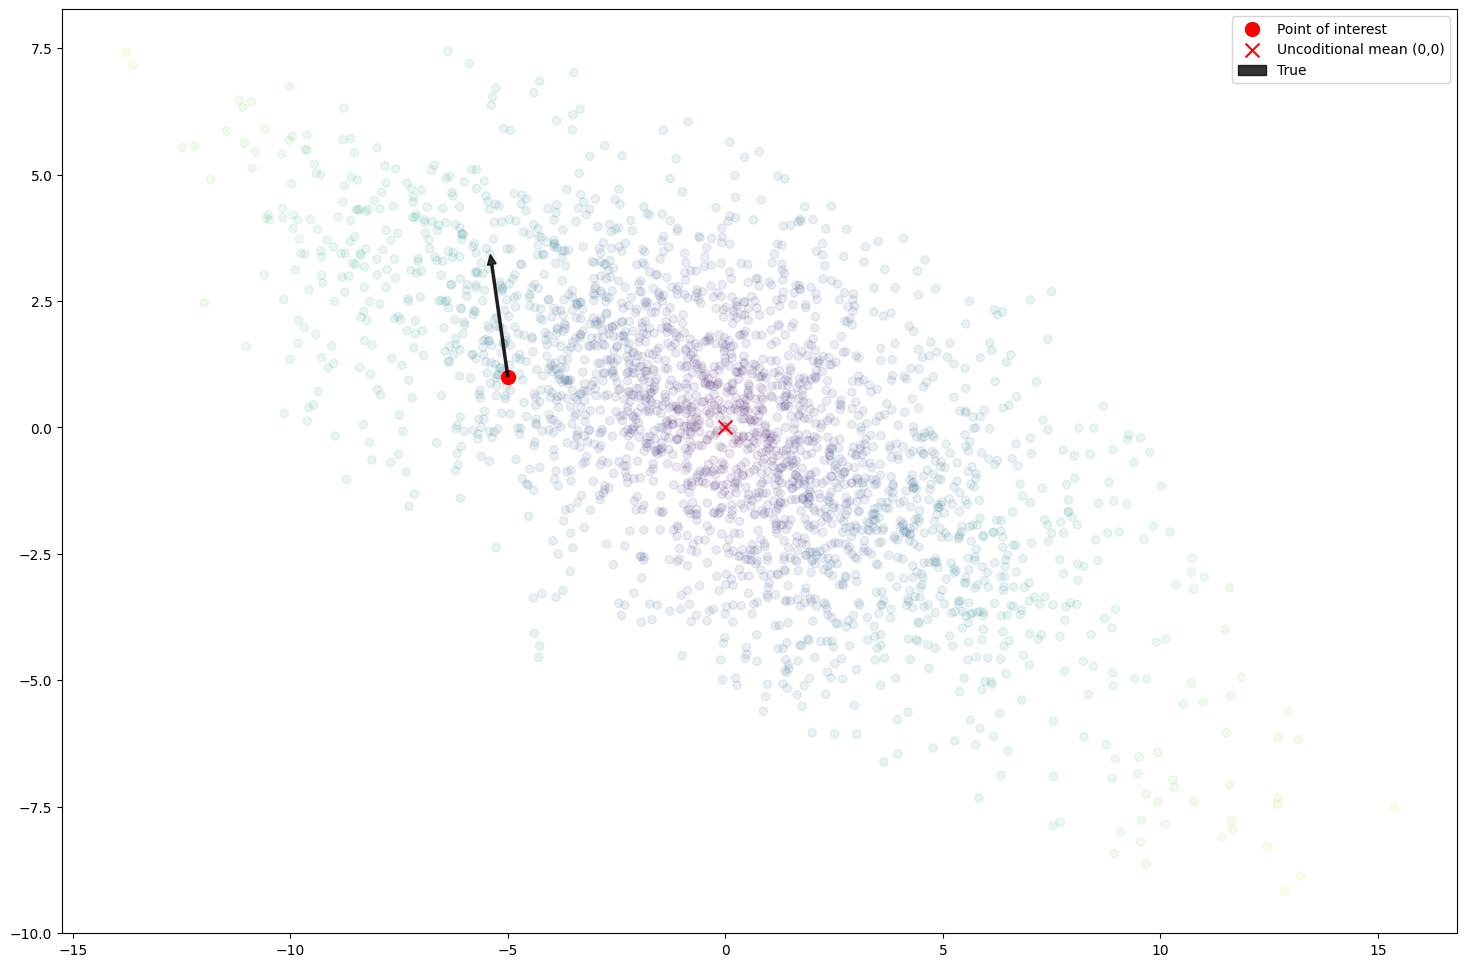

In [4]:
# We color each point based on its distance from (0,0)
color_array = np.linalg.norm(X, axis = 1) ** .8

plt.scatter(X[:,0], X[:,1], c = color_array, alpha = .1)
plt.scatter(X0[0], X0[1], color = 'red', s = 100, label = 'Point of interest')
plt.scatter(mean[0][0], mean[1][0], color = 'red', s = 100, marker = 'x', label = 'Uncoditional mean (0,0)')
# plt.arrow(X0[0], X0[1], 7 * a.item(0), 7 * a.item(1), head_width=0.8, head_length=0.8, width = 0.2, color = 'red', label = 'True')
plt.arrow(X0[0], X0[1], 7 * true_directional_vector[0], 7 * true_directional_vector[1], head_width=0.2, head_length=0.2, width = 0.05, color = 'black', label = 'True', alpha = .8)
plt.legend()
plt.show()

In [6]:
est_dir, est_dep, test = [], [], [] # Estimated lists
est_dir2, est_dep2, test = [], [], [] # Estimated lists

rel_depth1, rel_depth2 = [], []

for n in tqdm(samples):
    XN = X[:n]

    # Option degree to loop over the unit circle
    depth_estimator = Estimator(X = XN, X0 = X0, method = 'deg', num = n)

    # Option point_wise to loop over obervations projected on the unit circle
    depth_estimator2 = Estimator(X = XN, X0 = X0, method = 'point_wise')

    estimated_depth, estimated_direction, relative_angles, relative_depths, relative_directions = depth_estimator.main()
    estimated_depth2, estimated_direction2, relative_angles2, relative_depths2, relative_directions2 = depth_estimator2.main()

    rel_depth1.append(relative_depths)
    rel_depth2.append(relative_depths2)

    est_dir.append(estimated_direction)
    est_dep.append(estimated_depth)

    est_dir2.append(estimated_direction2)
    est_dep2.append(estimated_depth2)

100%|██████████| 49/49 [00:08<00:00,  5.81it/s]


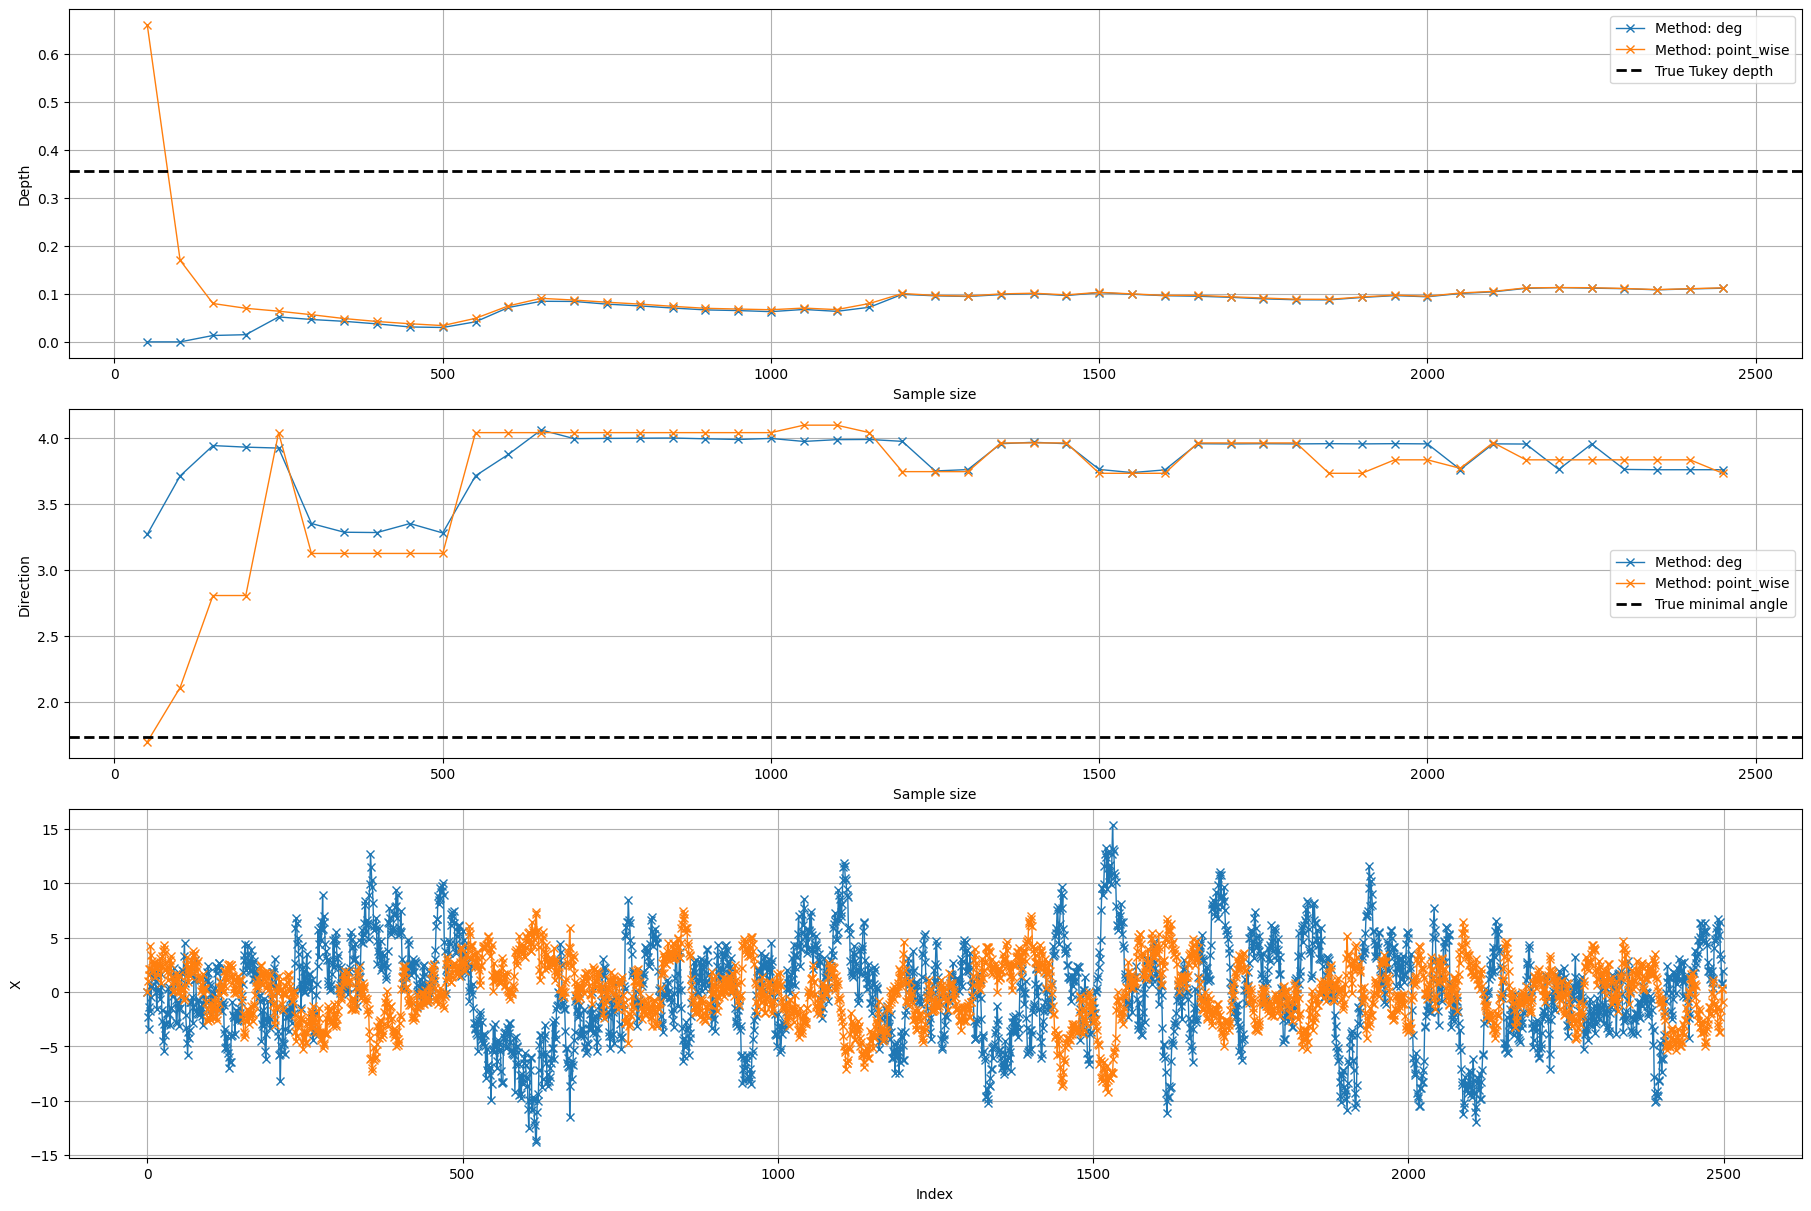

In [7]:
# Graph statistics
fig, axs = plt.subplots(3, 1, layout='constrained')
axs[0].plot(samples, est_dep, lw = 1, c = 'C0', marker = 'x', label = 'Method: deg')
axs[0].plot(samples, est_dep2, lw = 1, c = 'C1', marker = 'x', label = 'Method: point_wise')
axs[0].axhline(true_depth, color = 'black', linestyle = 'dashed', linewidth = 2, label = 'True Tukey depth')
axs[0].set_xlabel('Sample size')
axs[0].set_ylabel('Depth')
axs[0].grid(True)
axs[0].legend()

axs[1].plot(samples, est_dir, lw = 1, c = 'C0', marker = 'x', label = 'Method: deg')
axs[1].plot(samples, est_dir2, lw = 1, c = 'C1', marker = 'x', label = 'Method: point_wise')
axs[1].axhline(true_directional_angle, color = 'black', linestyle = 'dashed', linewidth = 2, label = 'True minimal angle')
axs[1].set_xlabel('Sample size')
axs[1].set_ylabel('Direction')
axs[1].grid(True)
axs[1].legend()
# axs[1].set_ylim([true_TP - np.pi / 8, true_TP + np.pi / 8])

axs[2].plot(X[:,0], lw = 1, c = 'C0', marker = 'x')
axs[2].plot(X[:,1], lw = 1, c = 'C1', marker = 'x')
axs[2].set_xlabel('Index')
axs[2].set_ylabel('X')
axs[2].grid(True)

plt.show()

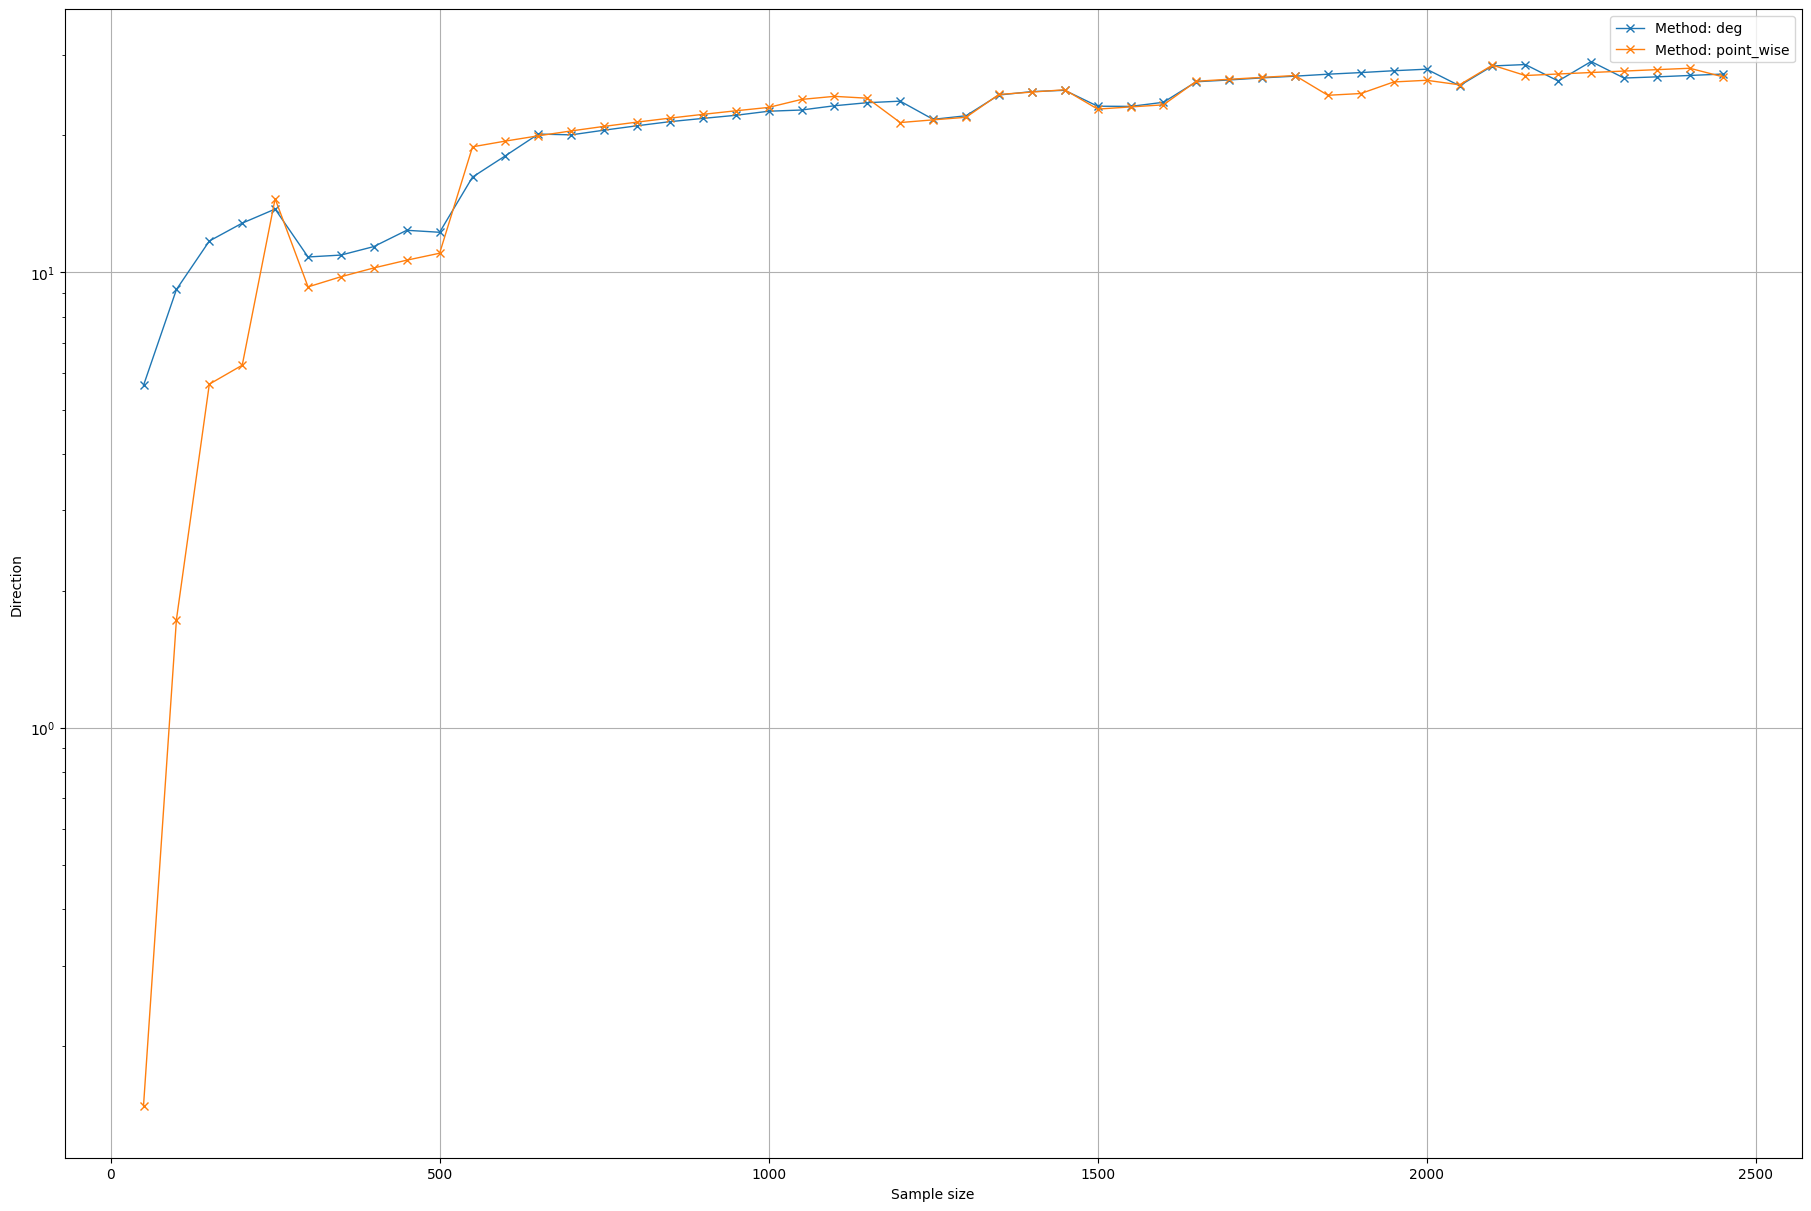

In [8]:
# Graph statistics
diff1 = est_dir-true_directional_angle
diff2 = est_dir2-true_directional_angle

fig, axs = plt.subplots(1, 1, layout='constrained')
axs.plot(samples, (np.array(samples) ** (1/3)) *  np.abs(diff1), lw = 1, c = 'C0', marker = 'x', label = 'Method: deg')
axs.plot(samples, (np.array(samples) ** (1/3)) *  np.abs(diff2), lw = 1, c = 'C1', marker = 'x', label = 'Method: point_wise')
axs.set_xlabel('Sample size')
axs.set_ylabel('Direction')
axs.grid(True)
axs.legend()
axs.set_yscale('log')
# axs[1].set_ylim([true_TP - np.pi / 8, true_TP + np.pi / 8])
plt.show()

In [9]:
# Graph minimal direction
X_shifted = XN - X0
X_projected = X_shifted / np.linalg.norm(X_shifted, axis = 1).T[:, np.newaxis]

estimated_minimal_vector = depth_estimator.Angle_to_vetor(estimated_direction, normalise = True)
estimated_minimal_vector2 = depth_estimator2.Angle_to_vetor(estimated_direction2, normalise = True)

In [15]:
np.linalg.eigvals(variance)

array([24.91601459, -3.37755305])

In [10]:
x, y = np.mgrid[-10:11:.1, -10:11:.1]
pos = np.dstack((x, y))
rv = scipy.stats.multivariate_normal(mean.T[0], variance)
fig2 = plt.figure()

ax1 = fig2.add_subplot(111)
ax1.set_xlim(-10,10)
ax1.set_ylim(-10,10)
ax1.contourf(x, y, rv.pdf(pos), levels = 20)
# ax1.scatter(X_test[:,0], X_test[:,1], c = color_array, cmap = 'Blues', alpha = .05)
ax1.scatter(X0[0], X0[1], color = 'red', marker = 'x')
# ax1.scatter(XN[:,0], XN[:,1], c = rel_depth2[-1])
ax1.plot([mean.T[0][0], X0[0]], [mean.T[0][1], X0[1]], color = 'red', linestyle = 'dashed')
ax1.scatter(X[:,0],X[:,1])
ax1.arrow(X0[0], X0[1], 2 * true_directional_vector[0], 2 * true_directional_vector[1], head_width=0.2, head_length=0.2, width = 0.02, color = 'black', label = 'True', alpha = .5)
ax1.arrow(X0[0], X0[1], 2 * estimated_minimal_vector.item(0), 2 * estimated_minimal_vector.item(1), head_width=0.2, head_length=0.2, width = 0.02, color = 'C0', label = "Estimated (deg)", alpha = 1)
ax1.arrow(X0[0], X0[1], 2 * estimated_minimal_vector2.item(0), 2 * estimated_minimal_vector2.item(1), head_width=0.2, head_length=0.2, width = 0.02, color = 'C1', label = "Estimated (point_wise)", alpha = 1)

ValueError: The input matrix must be symmetric positive semidefinite.

In [ ]:
plt.scatter(XN[:,0], XN[:,1], c = rel_depth2[-1])
plt.scatter(X0[0], X0[1], color = 'red', s = 100)
plt.scatter(mean[0][0], mean[1][0], color = 'red', s = 100, marker = 'x')
# plt.arrow(X0[0], X0[1], 7 * a.item(0), 7 * a.item(1), head_width=0.8, head_length=0.8, width = 0.2, color = 'red', label = 'True')
plt.arrow(X0[0], X0[1], 7 * true_directional_vector[0], 7 * true_directional_vector[1], head_width=0.8, head_length=0.8, width = 0.2, color = 'black', label = 'True', alpha = .5)
plt.arrow(X0[0], X0[1], 7 * estimated_minimal_vector.item(0), 7 * estimated_minimal_vector.item(1), head_width=0.8, head_length=0.8, width = 0.2, color = 'C0', label = "Estimated (deg)", alpha = 1)
plt.arrow(X0[0], X0[1], 7 * estimated_minimal_vector2.item(0), 7 * estimated_minimal_vector2.item(1), head_width=0.8, head_length=0.8, width = 0.2, color = 'C1', label = "Estimated (point_wise)", alpha = 1)
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import display, clear_output

diff1_main = np.abs(est_dir-true_directional_angle)
diff2_main = np.abs(est_dir2-true_directional_angle)

ub = max(np.abs(max(diff1_main)), np.abs(max(diff2_main)))
lb = min(min(diff1_main), min(diff2_main))
for idx, n in enumerate(samples):
    XN = X[:n]

    X_shifted = XN - X0
    X_projected = X_shifted / np.linalg.norm(X_shifted, axis = 1).T[:, np.newaxis]

    estimated_minimal_vector = depth_estimator.Angle_to_vetor(est_dir[idx], normalise = True)
    estimated_minimal_vector2 = depth_estimator2.Angle_to_vetor(est_dir2[idx], normalise = True)

    diff1 = est_dir[:idx]-true_directional_angle
    diff2 = est_dir2[:idx]-true_directional_angle

    # Clear the previous plot
    clear_output(wait=True)
    
    # Create a new figure and plot
    fig, ax = plt.subplots(2,1)
    ax[0].set_xlim(-1.2 * max(np.abs(X[:,0])), 1.2 * max(np.abs(X[:,0])))
    ax[0].set_ylim(-1.2 * max(np.abs(X[:,1])), 1.2 * max(np.abs(X[:,1])))

    ax[0].scatter(XN[:,0], XN[:,1], c = rel_depth2[idx])
    ax[0].scatter(X0[0], X0[1], color = 'red', s = 100)
    ax[0].scatter(mean[0][0], mean[1][0], color = 'red', s = 100, marker = 'x')
    # plt.arrow(X0[0], X0[1], 7 * a.item(0), 7 * a.item(1), head_width=0.8, head_length=0.8, width = 0.2, color = 'red', label = 'True')
    ax[0].arrow(X0[0], X0[1], 7 * true_directional_vector[0], 7 * true_directional_vector[1], head_width=0.8, head_length=0.8, width = 0.2, color = 'black', label = 'True', alpha = .5)
    ax[0].arrow(X0[0], X0[1], 7 * estimated_minimal_vector.item(0), 7 * estimated_minimal_vector.item(1), head_width=0.8, head_length=0.8, width = 0.2, color = 'C0', label = "Estimated (deg)", alpha = 1)
    ax[0].arrow(X0[0], X0[1], 7 * estimated_minimal_vector2.item(0), 7 * estimated_minimal_vector2.item(1), head_width=0.8, head_length=0.8, width = 0.2, color = 'C1', label = "Estimated (point_wise)", alpha = 1)
    ax[0].legend()
    ax[0].set_title(f'Sample size : {n}')

    ax[1].set_xlim(0, N_samples)
    # ax[1].set_ylim(lb, ub)
    ax[1].plot(samples[:idx], (np.array(samples[:idx]) ** (1/3)) *  np.abs(diff1), lw = 1, c = 'C0', marker = 'x', label = 'Method: deg')
    ax[1].plot(samples[:idx], (np.array(samples[:idx]) ** (1/3)) *  np.abs(diff2), lw = 1, c = 'C1', marker = 'x', label = 'Method: point_wise')
    ax[1].set_xlabel('Sample size')
    ax[1].set_ylabel('Direction')
    ax[1].grid(True)
    ax[1].legend()
    ax[1].set_yscale('log')
    plt.show()

    # Pause for 0.5 seconds
    time.sleep(0.01)


## Example 

In [2]:
from functionalcurves.mixing_models import MixingMarkovModel, transition_diff, transition_markov

In [ ]:
Markov_chain = MixingMarkovModel(mixing_rate = 1, transition_function=transition_diff)

true_directional_vector = np.array([0,1])
mean = np.array([0,0])

X0 = np.array((0, 1.5))           # Depth point
est_dir, est_dep, test = [], [], [] # Estimated lists
est_dir2, est_dep2, test = [], [], [] # Estimated lists
N_samples, jump = 10_000, 50         # Simulation parameters

X = Markov_chain.simulate(n_samples = N_samples, rho = .99)
samples = range(jump, N_samples, jump)

rel_depth1, rel_depth2 = [], []

for n in tqdm(samples):
    XN = X[:n]
    depth_estimator = Estimator(X = XN, X0 = X0, method = 'deg')
    depth_estimator2 = Estimator(X = XN, X0 = X0, method = 'point_wise')

    estimated_depth, estimated_direction, relative_angles, relative_depths, relative_directions = depth_estimator.main()
    estimated_depth2, estimated_direction2, relative_angles2, relative_depths2, relative_directions2 = depth_estimator2.main()

    rel_depth1.append(relative_depths)
    rel_depth2.append(relative_depths2)

    est_dir.append(estimated_direction)
    est_dep.append(estimated_depth)

    est_dir2.append(estimated_direction2)
    est_dep2.append(estimated_depth2)
    

In [ ]:
# Graph statistics
fig, axs = plt.subplots(3, 1, layout='constrained')
axs[0].plot(samples, est_dep, lw = 1, c = 'C0', marker = 'x', label = 'Method: deg')
axs[0].plot(samples, est_dep2, lw = 1, c = 'C1', marker = 'x', label = 'Method: point_wise')
axs[0].set_xlabel('Sample size')
axs[0].set_ylabel('Depth')
axs[0].grid(True)
axs[0].legend()

axs[1].plot(samples, est_dir, lw = 1, c = 'C0', marker = 'x', label = 'Method: deg')
axs[1].plot(samples, est_dir2, lw = 1, c = 'C1', marker = 'x', label = 'Method: point_wise')
axs[1].set_xlabel('Sample size')
axs[1].set_ylabel('Direction')
axs[1].grid(True)
axs[1].legend()
# axs[1].set_ylim([true_TP - np.pi / 8, true_TP + np.pi / 8])

axs[2].plot(X[:,0], lw = 1, c = 'C0', marker = 'x')
axs[2].plot(X[:,1], lw = 1, c = 'C1', marker = 'x')
axs[2].set_xlabel('Index')
axs[2].set_ylabel('X')
axs[2].grid(True)

plt.show()

In [ ]:
# Graph minimal direction
X_shifted = XN - X0
X_projected = X_shifted / np.linalg.norm(X_shifted, axis = 1).T[:, np.newaxis]

estimated_minimal_vector = depth_estimator.Angle_to_vetor(estimated_direction, normalise = True)
estimated_minimal_vector2 = depth_estimator2.Angle_to_vetor(estimated_direction2, normalise = True)

plt.scatter(XN[:,0], XN[:,1], c = relative_depths2)
plt.scatter(X0[0], X0[1], color = 'red', s = 100)
plt.scatter(mean[0], mean[1], color = 'red', s = 100, marker = 'x')
plt.arrow(X0[0], X0[1], 2 * true_directional_vector[0], 2 * true_directional_vector[1], head_width=0.2, head_length=0.2, width = 0.05, color = 'black', label = 'True', alpha = .5)
plt.arrow(X0[0], X0[1], 2 * estimated_minimal_vector.item(0), 1.8 * estimated_minimal_vector.item(1), head_width=0.2, head_length=0.2, width = 0.05, color = 'C0', label = "Estimated (deg)", alpha = 1)
plt.arrow(X0[0], X0[1], 2 * estimated_minimal_vector2.item(0), 1.6 * estimated_minimal_vector2.item(1), head_width=0.2, head_length=0.2, width = 0.05, color = 'C1', label = "Estimated (point_wise)", alpha = 1)
plt.legend()
plt.show()



In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import display, clear_output

true_directional_angle = np.float64(np.pi / 2)
diff1_main = np.abs(est_dir-true_directional_angle)
diff2_main = np.abs(est_dir2-true_directional_angle)

ub = max(np.abs(max(diff1_main)), np.abs(max(diff2_main)))
lb = min(min(diff1_main), min(diff2_main)) / 2
for idx, n in enumerate(samples):
    XN = X[:n]

    X_shifted = XN - X0
    X_projected = X_shifted / np.linalg.norm(X_shifted, axis = 1).T[:, np.newaxis]

    estimated_minimal_vector = depth_estimator.Angle_to_vetor(est_dir[idx], normalise = True)
    estimated_minimal_vector2 = depth_estimator2.Angle_to_vetor(est_dir2[idx], normalise = True)

    diff1 = est_dir[:idx]-true_directional_angle
    diff2 = est_dir2[:idx]-true_directional_angle

    # Clear the previous plot
    clear_output(wait=True)
    
    # Create a new figure and plot
    fig, ax = plt.subplots(3,1, figsize = (12,12))
    # ax[0].set_xlim(-1.2 * max(np.abs(X[:,0])), 1.2 * max(np.abs(X[:,0])))
    # ax[0].set_ylim(-1.2 * max(np.abs(X[:,1])), 1.2 * max(np.abs(X[:,1])))

    ax[0].scatter(XN[:,0], XN[:,1], c = rel_depth2[idx])
    ax[0].scatter(X0[0], X0[1], color = 'red', s = 100)
    ax[0].scatter(mean[0], mean[1], color = 'red', s = 100, marker = 'x')
    # plt.arrow(X0[0], X0[1], 7 * a.item(0), 7 * a.item(1), head_width=0.8, head_length=0.8, width = 0.2, color = 'red', label = 'True')
    ax[0].arrow(X0[0], X0[1], 2 * true_directional_vector[0], 2 * true_directional_vector[1], head_width=0.2, head_length=0.2, width = 0.05, color = 'black', label = 'True', alpha = .5)
    ax[0].arrow(X0[0], X0[1], 2 * estimated_minimal_vector.item(0), 1.8 * estimated_minimal_vector.item(1), head_width=0.2, head_length=0.2, width = 0.05, color = 'C0', label = "Estimated (deg)", alpha = 1)
    ax[0].arrow(X0[0], X0[1], 2 * estimated_minimal_vector2.item(0), 1.6 * estimated_minimal_vector2.item(1), head_width=0.2, head_length=0.2, width = 0.05, color = 'C1', label = "Estimated (point_wise)", alpha = 1)
    ax[0].legend()
    ax[0].set_title(f'Sample size : {n}')

    ax[1].set_xlim(0, N_samples)
    # ax[1].set_ylim(lb, ub)
    ax[1].plot(samples[:idx], (np.array(samples[:idx]) ** (1/3)) *  np.abs(diff1), lw = 1, c = 'C0', marker = 'x', label = 'Method: deg')
    ax[1].plot(samples[:idx], (np.array(samples[:idx]) ** (1/3)) *  np.abs(diff2), lw = 1, c = 'C1', marker = 'x', label = 'Method: point_wise')
    ax[1].set_xlabel('Sample size')
    ax[1].set_ylabel('Direction')
    ax[1].grid(True)
    ax[1].legend()
    ax[1].set_yscale('linear')

    ax[2].set_xlim(0, N_samples)
    ax[2].plot(XN[:,0], lw = 1, c = 'C0', marker = 'x')
    ax[2].plot(XN[:,1], lw = 1, c = 'C1', marker = 'x')
    ax[2].set_xlabel('Index')
    ax[2].set_ylabel('X')
    ax[2].grid(True)
    plt.show()

    # Pause for 0.5 seconds
    time.sleep(0.01)


